In [1]:
# Cell 1 — Install
!pip install -q transformers==4.36.2 tokenizers==0.15.2 \
    torch pandas scikit-learn seaborn matplotlib

import subprocess, sys
result = subprocess.run([sys.executable, '-m', 'pip', 'show', 'transformers'],
    capture_output=True, text=True)
print(result.stdout.split('\n')[1])
print()
print('Install selesai!')
print('WAJIB: Klik Runtime > Restart Runtime, lalu mulai dari Cell 2')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.36.2 which is incompatible.
Version: 4.36.2

Install selesai!
WAJIB: Klik Runtime > Restart Runtime, lalu mulai dari Cell 2


In [1]:
# Cell 2 — Imports
import os, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

import transformers as _tf
print(f'PyTorch      : {torch.__version__}')
print(f'Transformers : {_tf.__version__}')
print(f'GPU available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'  -> {torch.cuda.get_device_name(0)}')


/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


PyTorch      : 2.11.0+cu128
Transformers : 4.36.2
GPU available: True
  -> Tesla T4


In [2]:
# Cell 3 — Konfigurasi
CSV_PATH   = '/content/gopay_augmented.csv'   # ganti ke gopay_labeled.csv jika belum relabel

MODEL_NAME = 'indobenchmark/indobert-base-p1'
LABEL_MAP  = {'negatif': 0, 'netral': 1, 'positif': 2}
ID2LABEL   = {0: 'negatif', 1: 'netral', 2: 'positif'}
MAX_LEN    = 128
BATCH_SIZE = 16
EPOCHS     = 5
LR         = 2e-5
TEST_SIZE  = 0.2
SEED       = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print('Konfigurasi siap')


Device : cuda
Konfigurasi siap


In [3]:
# Cell 4 — Load dataset
df = pd.read_csv(CSV_PATH)
df = df[df['label'].isin(LABEL_MAP)].copy()
df['label_id'] = df['label'].map(LABEL_MAP)
df['full_text'] = df['full_text'].astype(str).str[:512]

print(f'Total samples : {len(df)}')
print('Distribusi label:')
print(df['label'].value_counts().to_string())


Total samples : 691
Distribusi label:
label
netral     391
positif    150
negatif    150


In [4]:
# Cell 5 — Text Cleansing
import re

def clean_tweet(text: str) -> str:
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)   # hapus URL
    text = re.sub(r'@\w+', '', text)                  # hapus mention
    text = re.sub(r'#(\w+)', r'\1', text)            # hapus simbol #, simpan kata
    text = re.sub(r'\bRT\b', '', text)               # hapus RT
    text = re.sub(r'[^\w\s]', ' ', text)             # hapus tanda baca & simbol
    text = re.sub(r'\d+', '', text)                   # hapus angka
    text = re.sub(r'\s+', ' ', text).strip()          # normalisasi spasi
    text = text.lower()
    return text


df['clean_text'] = df['full_text'].apply(clean_tweet)

before = len(df)
df = df[df['clean_text'].str.strip().str.len() > 3].copy()
print(f'Baris valid setelah cleansing : {len(df)} (dihapus: {before - len(df)})')

# Split menggunakan clean_text
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'].tolist(),
    df['label_id'].tolist(),
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df['label_id']
)
print(f'Train : {len(X_train)} | Test : {len(X_test)}')

# Preview
print('\nContoh cleansing:')
for raw, clean in zip(df['full_text'].head(3), df['clean_text'].head(3)):
    print(f'  BEFORE: {raw[:80]}')
    print(f'  AFTER : {clean[:80]}')
    print()

Baris valid setelah cleansing : 691 (dihapus: 0)
Train : 552 | Test : 139

Contoh cleansing:
  BEFORE: @askmenfess Apknya lemot atmnya masih jarang ga kena charge kalo saldo +- 1 juta
  AFTER : apknya lemot atmnya masih jarang ga kena charge kalo saldo jutaan kalo dibawah i

  BEFORE: Saya selalu pakai uang digital jajan mall punya cashback banyak promo.
  AFTER : saya selalu pakai uang digital jajan mall punya cashback banyak promo

  BEFORE: Katanya mergernya dana dan ovo untuk mengurangi aksi bakar uang sekaligus menyai
  AFTER : katanya mergernya dana dan ovo untuk mengurangi aksi bakar uang sekaligus menyai



In [5]:
# Cell 6 — Hitung class weight (atasi class imbalance)
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=df['label_id'].tolist()
)
class_weights = torch.tensor(weights, dtype=torch.float).to(DEVICE)

print('Class weights — semakin tinggi = model makin fokus ke kelas itu:')
for label, w in zip(['negatif', 'netral', 'positif'], weights):
    bar = chr(9608) * int(w * 8)
    print(f'  {label:8s}: {w:.3f}  {bar}')

criterion = nn.CrossEntropyLoss(weight=class_weights)
print('\ncriterion dengan class weight siap')

Class weights — semakin tinggi = model makin fokus ke kelas itu:
  negatif : 1.536  ████████████
  netral  : 0.589  ████
  positif : 1.536  ████████████

criterion dengan class weight siap


In [6]:
# Cell 7 — Dataset class & DataLoader
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }


print('Loading tokenizer...')
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

train_ds = SentimentDataset(X_train, y_train, tokenizer, MAX_LEN)
test_ds  = SentimentDataset(X_test,  y_test,  tokenizer, MAX_LEN)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f'Train batches : {len(train_dl)}')
print(f'Test  batches : {len(test_dl)}')

Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Train batches : 35
Test  batches : 9


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [7]:
# Cell 8 — Load IndoBERT
print('Loading IndoBERT...')
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL_MAP
)
model.to(DEVICE)

total_p   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total_p:,}')
print(f'Trainable params: {trainable:,}')


Loading IndoBERT...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total params    : 124,443,651
Trainable params: 124,443,651


In [8]:
# Cell 9 — Helper: fungsi evaluasi
def eval_model(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            lbls = batch['labels'].to(DEVICE)
            out  = model(ids, attention_mask=mask)
            pred = torch.argmax(out.logits, dim=-1)
            preds.extend(pred.cpu().numpy())
            trues.extend(lbls.cpu().numpy())
    return trues, preds

print('Fungsi eval_model siap')

Fungsi eval_model siap


In [9]:
# Cell 10 — Fine-tuning dengan class weight
optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_dl) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

train_losses, val_accs = [], []
SEP = '=' * 55
print(SEP)
print(f'  Training IndoBERT — {EPOCHS} epochs, lr={LR}')
print(f'  Loss  : CrossEntropyLoss + class weight')
print(SEP)

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    for step, batch in enumerate(train_dl):
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbls = batch['labels'].to(DEVICE)
        optimizer.zero_grad()
        out  = model(ids, attention_mask=mask)
        loss = criterion(out.logits, lbls)   # weighted loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_dl)
    train_losses.append(avg_loss)
    y_true, y_pred = eval_model(model, test_dl)
    acc = accuracy_score(y_true, y_pred)
    val_accs.append(acc)
    print(f'Epoch {epoch}/{EPOCHS}  |  Loss: {avg_loss:.4f}  |  Val Acc: {acc*100:.2f}%')

print()
print('Training selesai!')

  Training IndoBERT — 5 epochs, lr=2e-05
  Loss  : CrossEntropyLoss + class weight
Epoch 1/5  |  Loss: 0.9624  |  Val Acc: 74.82%
Epoch 2/5  |  Loss: 0.4584  |  Val Acc: 80.58%
Epoch 3/5  |  Loss: 0.1995  |  Val Acc: 85.61%
Epoch 4/5  |  Loss: 0.0904  |  Val Acc: 86.33%
Epoch 5/5  |  Loss: 0.0587  |  Val Acc: 86.33%

Training selesai!


  HASIL EVALUASI AKHIR
Accuracy : 86.33%

              precision    recall  f1-score   support

     negatif       0.79      0.73      0.76        30
      netral       0.89      0.90      0.89        79
     positif       0.87      0.90      0.89        30

    accuracy                           0.86       139
   macro avg       0.85      0.84      0.85       139
weighted avg       0.86      0.86      0.86       139



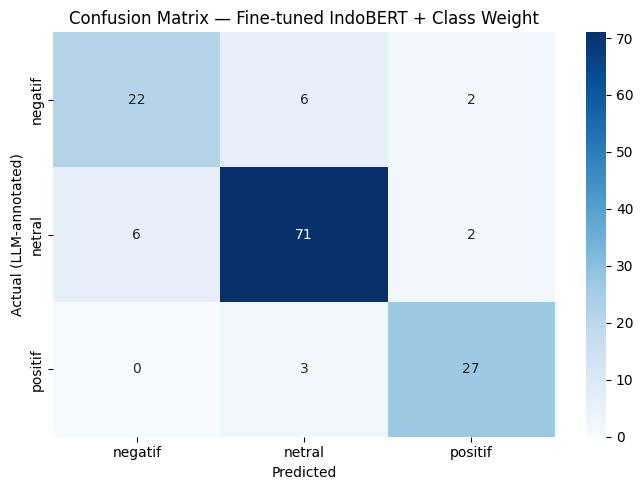

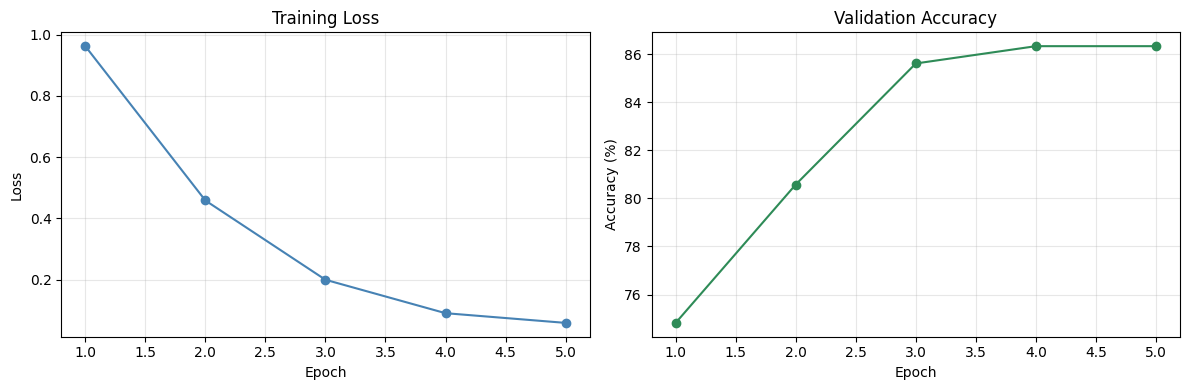

Grafik tersimpan: confusion_matrix.png, training_curves.png


In [10]:
# Cell 11 — Evaluasi akhir
y_true, y_pred = eval_model(model, test_dl)

SEP = '=' * 55
print(SEP)
print('  HASIL EVALUASI AKHIR')
print(SEP)
print(f'Accuracy : {accuracy_score(y_true, y_pred)*100:.2f}%')
print()
print(classification_report(
    y_true, y_pred,
    target_names=['negatif', 'netral', 'positif']
))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negatif', 'netral', 'positif'],
            yticklabels=['negatif', 'netral', 'positif'])
plt.title('Confusion Matrix — Fine-tuned IndoBERT + Class Weight')
plt.xlabel('Predicted')
plt.ylabel('Actual (LLM-annotated)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Loss & accuracy curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(1, EPOCHS+1), train_losses, marker='o', color='steelblue')
ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)
ax2.plot(range(1, EPOCHS+1), [a*100 for a in val_accs], marker='o', color='seagreen')
ax2.set_title('Validation Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('Grafik tersimpan: confusion_matrix.png, training_curves.png')

In [11]:
# Cell 12 — Simpan model & hasil prediksi
SAVE_DIR = 'indobert_gopay'
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f'Model tersimpan: {SAVE_DIR}/')

result_df = pd.DataFrame({
    'full_text':       X_test,
    'true_label':      [ID2LABEL[i] for i in y_true],
    'predicted_label': [ID2LABEL[i] for i in y_pred],
    'correct':         [t == p for t, p in zip(y_true, y_pred)]
})
result_df.to_csv('gopay_evaluated.csv', index=False)
print('Hasil prediksi tersimpan: gopay_evaluated.csv')

try:
    from google.colab import files
    for fn in ['confusion_matrix.png', 'training_curves.png', 'gopay_evaluated.csv']:
        files.download(fn)
    print('File didownload ke komputer')
except ImportError:
    print('Bukan Colab — download manual dari Files panel')

Model tersimpan: indobert_gopay/
Hasil prediksi tersimpan: gopay_evaluated.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File didownload ke komputer
